In [15]:
import numpy as np
import pandas as pd
import torch

import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
result_dir = "../__saved__/results/evaluation/161858_process_datasets.csv"
result_dir = "../__saved__/results/evaluation/161948_compare_role_types.csv"
result_dir = "../__saved__/results/evaluation/161910_process_datasets.csv"
result_dir = "../../__saved__/results/evaluation/03164045_dgsda_evaluation.csv"
result_dir = "../../__saved__/results/evaluation/03164519_dgsda_evaluation.csv"
df1 = pd.read_csv(result_dir)
df1

,micro_f1,macro_f1,source,target,model,seed,train_time,status,repeat,cur_time,use_tuned
0,0.831114,0.820237,ACMv9,Citationv1,dgsda_probe,0,47.789998,ok,0,31646,0
1,0.744165,0.723807,ACMv9,DBLPv7,dgsda_probe,0,34.998118,ok,0,31646,0
2,0.766776,0.749315,Citationv1,DBLPv7,dgsda_probe,0,35.002489,ok,0,31647,0
3,0.829211,0.813512,ACMv9,Citationv1,dgsda,0,29.288512,ok,0,31647,0
4,0.765135,0.740373,ACMv9,DBLPv7,dgsda,0,28.248151,ok,0,31648,0
5,0.779905,0.761242,Citationv1,DBLPv7,dgsda,0,28.163942,ok,0,31648,0
6,0.827196,0.816316,ACMv9,Citationv1,dgsda_probe,1,46.168634,ok,1,31649,0
7,0.751641,0.728279,ACMv9,DBLPv7,dgsda_probe,1,35.205844,ok,1,31650,0
8,0.774982,0.755933,Citationv1,DBLPv7,dgsda_probe,1,35.026882,ok,1,31650,0
9,0.834919,0.821209,ACMv9,Citationv1,dgsda,1,29.263821,ok,1,31651,0


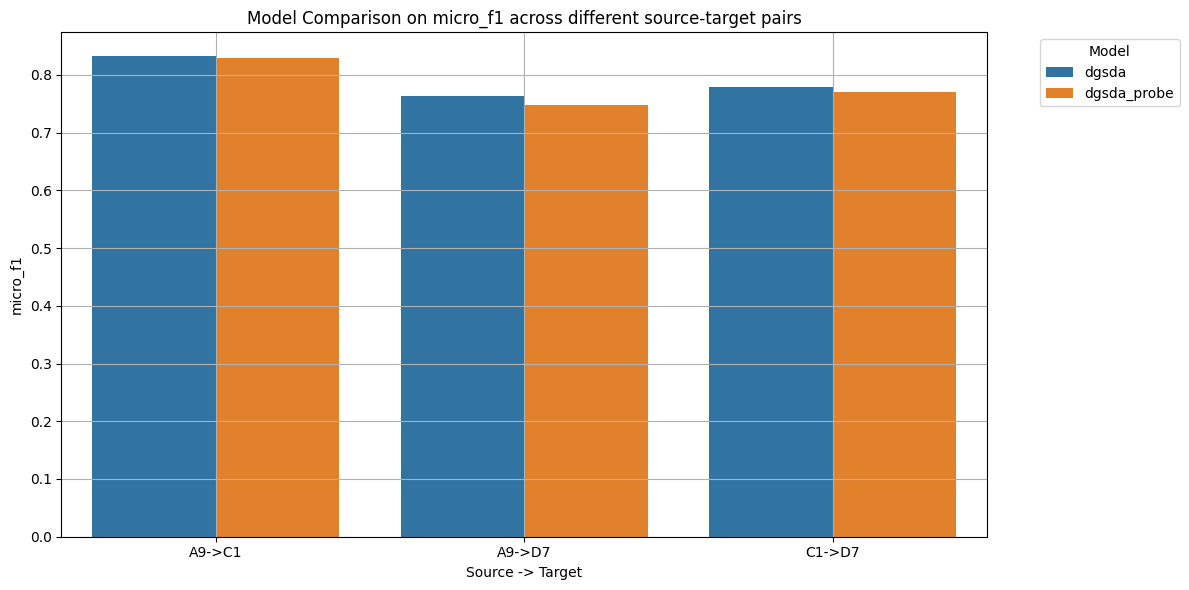

In [17]:
metrics = ["micro_f1", "macro_f1"]
plot_metric = metrics[0]  # choose metric to plot

df1["s->t"] = df1["source"].str[0] + df1["source"].str[-1] + "->" + df1["target"].str[0] + df1["target"].str[-1]

# let's compare each model on each s->t (group by s->t and model)
grouped_df1 = df1.groupby(["s->t", "model"])[plot_metric].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=grouped_df1, x="s->t", y=plot_metric, hue="model")
plt.title(f"Model Comparison on {plot_metric} across different source-target pairs")
plt.ylabel(plot_metric)
plt.xlabel("Source -> Target")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid()
plt.show()

Summary Table (Mean ± Std across seeds):


,s->t,model,micro_f1_mean,micro_f1_std,macro_f1_mean,macro_f1_std
0,A9->C1,dgsda,0.8321,0.0040,0.8174,0.0054
1,A9->C1,dgsda_probe,0.8292,0.0028,0.8183,0.0028
2,A9->D7,dgsda,0.7639,0.0017,0.7434,0.0043
3,A9->D7,dgsda_probe,0.7479,0.0053,0.7260,0.0032
4,C1->D7,dgsda,0.7795,0.0005,0.7611,0.0003
5,C1->D7,dgsda_probe,0.7709,0.0058,0.7526,0.0047


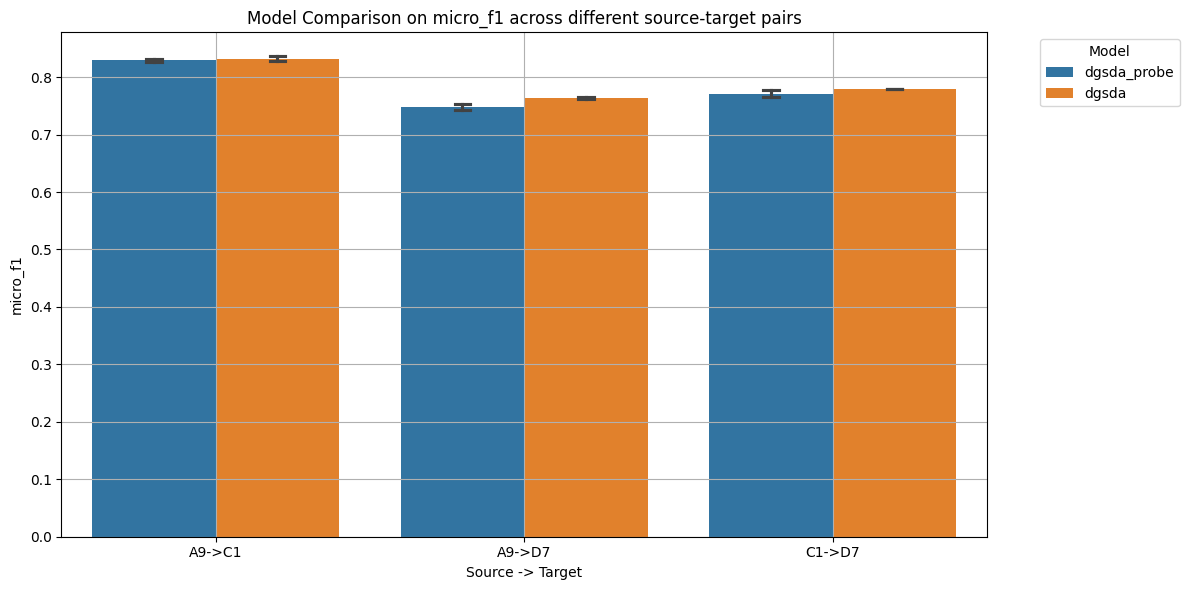

In [18]:
metrics = ["micro_f1", "macro_f1"]
plot_metric = metrics[0]  # choose metric to plot

df1["s->t"] = df1["source"].str[0] + df1["source"].str[-1] + "->" + df1["target"].str[0] + df1["target"].str[-1]

# Create summary table with mean and std for each metric
summary_table = df1.groupby(["s->t", "model"]).agg(
    {m: ["mean", "std"] for m in metrics}
).round(4)

# Flatten column names
summary_table.columns = [f"{m}_{stat}" for m, stat in summary_table.columns]
summary_table = summary_table.reset_index()

print("Summary Table (Mean ± Std across seeds):")
display(summary_table)

# Create grouped data for plotting
grouped_df1 = df1.groupby(["s->t", "model"])[plot_metric].agg(["mean", "std"]).reset_index()

# Plot with error bars
plt.figure(figsize=(12, 6))
sns.barplot(data=df1, x="s->t", y=plot_metric, hue="model", errorbar="sd", capsize=0.1)
plt.title(f"Model Comparison on {plot_metric} across different source-target pairs")
plt.ylabel(plot_metric)
plt.xlabel("Source -> Target")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid()
plt.show()

In [19]:
# [-1, 2, 1, 10]
# label_diffusion = 4xk
# let's say you have 4 classes, [0.1, 0.2, 0.1, 0.6] 
# x = [1, 0] [0, 1], [0, 1] [0, 1], [0, 1]

# logits = f(x, a)

# argmax = np.argmax(label_diffusion[0])
# role = label_diffusion[argmax, :] # 1xk
